In [1]:
from datetime import datetime
import torch
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
from torchsummary import summary
import matplotlib.pyplot as plt

#### Loading the Data

In [2]:
training_data = datasets.FashionMNIST(
    root="../data",
    train=True,
    download=True,
    transform=ToTensor()
)
test_data = datasets.FashionMNIST(
    root="../data",
    train=False,
    download=True,
    transform=ToTensor()
)
print(training_data)
print(test_data)

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: ../data
    Split: Train
    StandardTransform
Transform: ToTensor()
Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: ../data
    Split: Test
    StandardTransform
Transform: ToTensor()


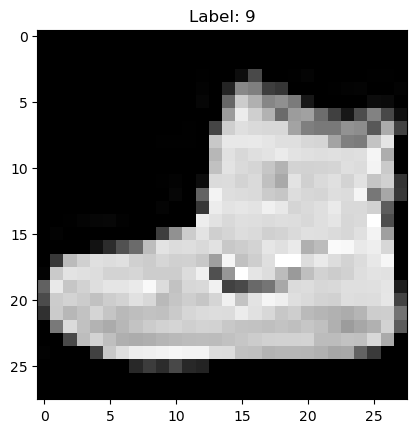

In [3]:
img, label = training_data[0]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.show()

In [29]:
import math
def plot_training(nepochs, cost_hist, cost_hist_test, acc_hist, acc_hist_test, minacc=None):
    plt.figure(1)
    plt.plot(torch.arange(nepochs), cost_hist, "-", label='train')
    plt.plot(torch.arange(nepochs), cost_hist_test, "r-", label='test')
    mincost = max(max(cost_hist),1.0)
    plt.xlabel("Epoch")
    plt.xlim(0,nepochs)
    plt.ylim(0,mincost)
    plt.title("Cross-Entropy Cost")
    plt.legend()
    plt.figure(2)
    plt.plot(torch.arange(nepochs), acc_hist,"-", label='train')
    plt.plot(torch.arange(nepochs), acc_hist_test,"r-", label='test')
    if not minacc:
        minacc = min(min(acc_hist),0.8)
    plt.xlabel("Epoch")
    plt.xlim(0,nepochs)
    plt.ylim(minacc,1)
    plt.legend()
    plt.title("Accuracy")

#### CNN

In [11]:
class CNN(torch.nn.Module):
    
    def __init__(self, nhidden1=256, nhidden2=64, noutput=10):
        super(CNN, self).__init__()
        self.layers = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1, bias=True),
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, bias=True),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            torch.nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1, bias=True),
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, bias=True),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            torch.nn.Flatten(),
            torch.nn.Linear(7*7*64, nhidden1),
            torch.nn.ReLU(),
            torch.nn.Linear(nhidden1, nhidden2),
            torch.nn.ReLU(),
            torch.nn.Linear(nhidden2, noutput)
        ) 
    
    def forward(self, x):
        z = self.layers(x)
        return z


In [12]:
model = CNN()

In [13]:
summary(model, (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
              ReLU-2           [-1, 32, 28, 28]               0
            Conv2d-3           [-1, 32, 28, 28]           9,248
              ReLU-4           [-1, 32, 28, 28]               0
         MaxPool2d-5           [-1, 32, 14, 14]               0
            Conv2d-6           [-1, 64, 14, 14]          18,496
              ReLU-7           [-1, 64, 14, 14]               0
            Conv2d-8           [-1, 64, 14, 14]          36,928
              ReLU-9           [-1, 64, 14, 14]               0
        MaxPool2d-10             [-1, 64, 7, 7]               0
          Flatten-11                 [-1, 3136]               0
           Linear-12                  [-1, 256]         803,072
             ReLU-13                  [-1, 256]               0
           Linear-14                   

#### GPU

In [14]:
device = None
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else: 
    device = torch.device("cpu")

print(device)

mps


In [17]:
def train_val(model, cost, epochs, train_loader, val_loader, optimizer, device):
    model = model.to(device)
    cost = cost.to(device)
    
    cost_hist = []
    cost_hist_test = []
    acc_hist = []
    acc_hist_test = []    
    train_samples = len(train_loader.dataset)
    val_samples = len(val_loader.dataset)
    train_batches = len(train_loader)
    val_batches = len(val_loader)
    for epoch in range(nepochs):
        cost, acc = 0.0, 0.0
        for batch, (X, Y) in enumerate(train_loader):
            X, Y = X.to(device), Y.to(device)
            pred = model(X)
            loss = cost_ce(pred, Y)
            cost += loss.item()
            acc += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()
    
            # gradient, parameter update
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        cost /= train_batches
        acc /= train_samples
    
        cost_val, acc_val = 0.0, 0.0
        with torch.no_grad():
            for batch, (X, Y) in enumerate(val_loader): 
                X, Y = X.to(device), Y.to(device)
                pred = model(X)
                cost_val += cost_ce(pred, Y).item()
                acc_val += (pred.argmax(dim=1) == Y).type(torch.float).sum().item()
            cost_val /= val_batches
            acc_val /= val_samples
        
        print("Epoch %i: %f, %f, %f, %f"%(epoch, cost, cost_val, acc, acc_val))
        cost_hist.append(cost)
        cost_hist_test.append(cost_val)
        acc_hist.append(acc)
        acc_hist_test.append(acc_val)

    return cost_hist, cost_hist_test, acc_hist, acc_hist_test

In [18]:
nbatch = 64
nepochs = 30
learning_rate = 0.04

model = CNN2Layer3MLPLayer()
cost_ce = torch.nn.CrossEntropyLoss()

train_loader = DataLoader(training_data, batch_size=nbatch, shuffle=True)
test_loader = DataLoader(test_data, batch_size=nbatch, shuffle=False)

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

cost_hist, cost_hist_test, acc_hist, acc_hist_test = train_val(model, cost_ce, nepochs, train_loader, test_loader, optimizer, device)

Epoch 0: 1.290344, 0.731855, 0.507117, 0.705100
Epoch 1: 0.547277, 0.542651, 0.789117, 0.799900
Epoch 2: 0.428294, 0.445904, 0.838267, 0.830200
Epoch 3: 0.367300, 0.530761, 0.861933, 0.804600
Epoch 4: 0.329354, 0.352993, 0.876650, 0.869900
Epoch 5: 0.302659, 0.327940, 0.886383, 0.876400
Epoch 6: 0.279217, 0.293833, 0.894900, 0.891500
Epoch 7: 0.260799, 0.295790, 0.902167, 0.889000
Epoch 8: 0.243983, 0.284798, 0.908750, 0.893600
Epoch 9: 0.229040, 0.286580, 0.914750, 0.896700
Epoch 10: 0.216501, 0.281419, 0.918467, 0.893800
Epoch 11: 0.205418, 0.260929, 0.923133, 0.907600
Epoch 12: 0.193505, 0.243282, 0.927433, 0.912200
Epoch 13: 0.182372, 0.258058, 0.931767, 0.903300
Epoch 14: 0.172224, 0.256157, 0.935683, 0.906700
Epoch 15: 0.165264, 0.226975, 0.938083, 0.919500
Epoch 16: 0.154245, 0.252030, 0.942033, 0.914500
Epoch 17: 0.146447, 0.234269, 0.945400, 0.919500
Epoch 18: 0.137360, 0.253774, 0.948833, 0.915200
Epoch 19: 0.128436, 0.239137, 0.951617, 0.921000
Epoch 20: 0.121118, 0.233709, 

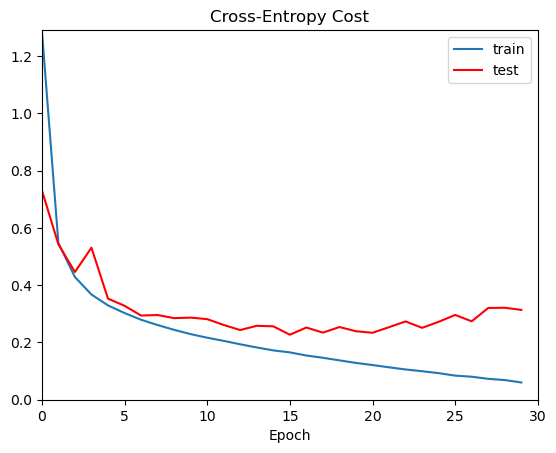

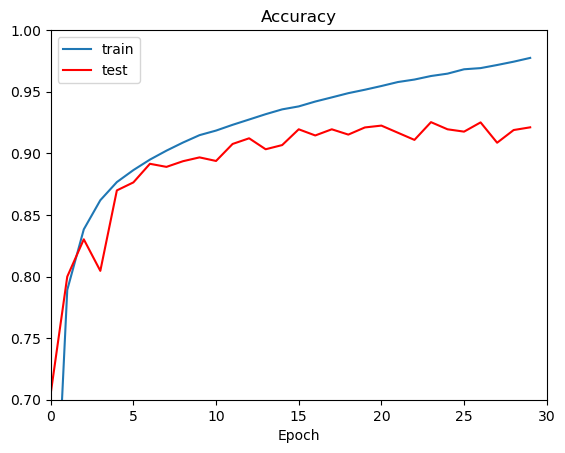

In [32]:
plot_training(nepochs, cost_hist, cost_hist_test, acc_hist, acc_hist_test, minacc=0.7)

### Batchnorm

In [22]:
class CNNWithBatchnorm(torch.nn.Module):
    
    def __init__(self, nhidden1=240, nhidden2=80, dropout_rate=0.7, noutput=10):
        super(CNNWithBatchnorm, self).__init__()
        self.layers = torch.nn.Sequential(
            torch.nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1, bias=True),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, bias=True),
            torch.nn.BatchNorm2d(32),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            torch.nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1, bias=True),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, bias=True),
            torch.nn.BatchNorm2d(64),
            torch.nn.ReLU(),
            torch.nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            torch.nn.Flatten(),
            torch.nn.Linear(7*7*64, nhidden1),
            torch.nn.BatchNorm1d(nhidden1),
            torch.nn.ReLU(),
            torch.nn.Linear(nhidden1, nhidden2),
            torch.nn.BatchNorm1d(nhidden2),
            torch.nn.ReLU(),
            torch.nn.Linear(nhidden2, noutput)
        ) 
    
    def forward(self, x):
        z = self.layers(x)
        return z


In [23]:
summary(CNNWithBatchnorm(), (1,28,28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 28, 28]             320
       BatchNorm2d-2           [-1, 32, 28, 28]              64
              ReLU-3           [-1, 32, 28, 28]               0
            Conv2d-4           [-1, 32, 28, 28]           9,248
       BatchNorm2d-5           [-1, 32, 28, 28]              64
              ReLU-6           [-1, 32, 28, 28]               0
         MaxPool2d-7           [-1, 32, 14, 14]               0
            Conv2d-8           [-1, 64, 14, 14]          18,496
       BatchNorm2d-9           [-1, 64, 14, 14]             128
             ReLU-10           [-1, 64, 14, 14]               0
           Conv2d-11           [-1, 64, 14, 14]          36,928
      BatchNorm2d-12           [-1, 64, 14, 14]             128
             ReLU-13           [-1, 64, 14, 14]               0
        MaxPool2d-14             [-1, 6

In [24]:
nbatch = 64
nepochs = 30
learning_rate = 0.04

model = CNNWithBatchnorm()
cost_ce = torch.nn.CrossEntropyLoss()

train_loader = DataLoader(training_data, batch_size=nbatch, shuffle=True)
test_loader = DataLoader(test_data, batch_size=nbatch, shuffle=False)

optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

cost_hist_do, cost_hist_test_do, acc_hist_do, acc_hist_test_do = train_val(model, cost_ce, nepochs, train_loader, test_loader, optimizer, device)

Epoch 0: 0.364785, 0.291236, 0.878233, 0.893800
Epoch 1: 0.221485, 0.257029, 0.920217, 0.907500
Epoch 2: 0.181483, 0.236273, 0.934867, 0.912800
Epoch 3: 0.152598, 0.241717, 0.944350, 0.912900
Epoch 4: 0.128135, 0.223726, 0.953550, 0.922100
Epoch 5: 0.111391, 0.227625, 0.959583, 0.923700
Epoch 6: 0.090503, 0.223328, 0.967883, 0.929600
Epoch 7: 0.074625, 0.227178, 0.972783, 0.928300
Epoch 8: 0.062634, 0.236010, 0.978150, 0.928400
Epoch 9: 0.049718, 0.248352, 0.982967, 0.927700
Epoch 10: 0.040013, 0.260922, 0.986083, 0.925100
Epoch 11: 0.029763, 0.260731, 0.990167, 0.932500
Epoch 12: 0.026022, 0.261596, 0.991450, 0.933000
Epoch 13: 0.023811, 0.269637, 0.992417, 0.932200
Epoch 14: 0.015653, 0.277265, 0.995467, 0.934300
Epoch 15: 0.014058, 0.276360, 0.996033, 0.929900
Epoch 16: 0.010871, 0.289811, 0.997150, 0.932600
Epoch 17: 0.007160, 0.302710, 0.998417, 0.930500
Epoch 18: 0.005080, 0.298468, 0.999150, 0.934800
Epoch 19: 0.004072, 0.304925, 0.999200, 0.934700
Epoch 20: 0.002920, 0.303393, 

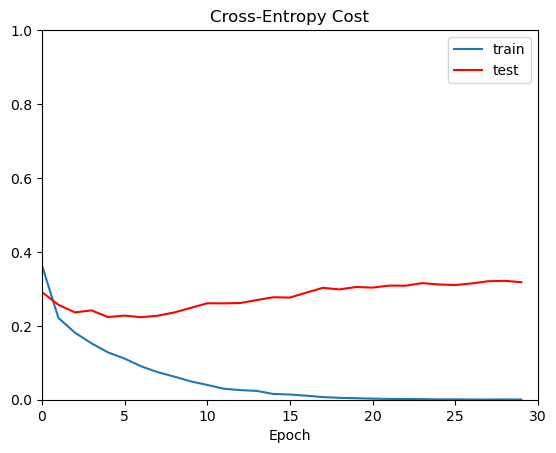

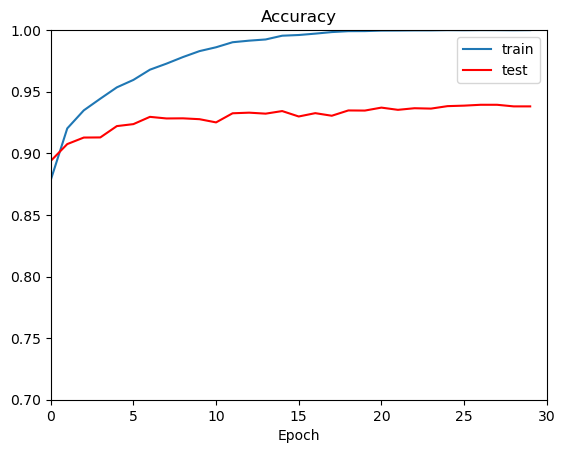

In [30]:
plot_training(nepochs, cost_hist_do, cost_hist_test_do, acc_hist_do, acc_hist_test_do, minacc=0.7)

In [26]:
def plot_two_runs(nepochs, cost_hist1, cost_hist_test1, cost_hist2, cost_hist_test2, title, low, high):
    epochs = torch.arange(nepochs)
    plt.plot(epochs, cost_hist1, "-", label='train 1')
    plt.plot(epochs, cost_hist_test1, "r-", label='test 1')
    plt.plot(epochs, cost_hist2, "--", label='train 2')
    plt.plot(epochs, cost_hist_test2, "r--", label='test 2')
    plt.xlabel("Epoch")
    plt.xlim(0,nepochs)
    plt.ylim(low, high)
    plt.title(title)
    plt.legend()

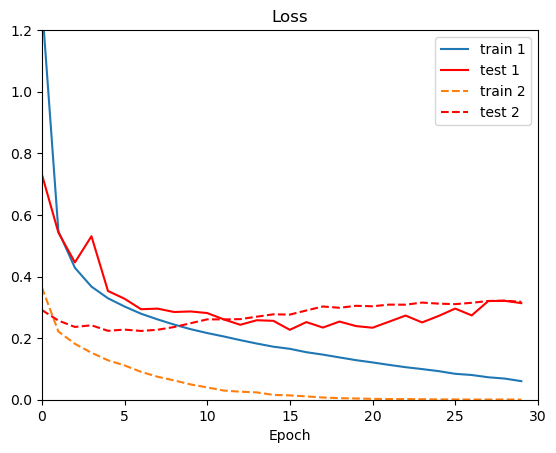

In [27]:
plot_two_runs(nepochs, cost_hist, cost_hist_test, cost_hist_do, cost_hist_test_do, "Loss", 0,1.2)

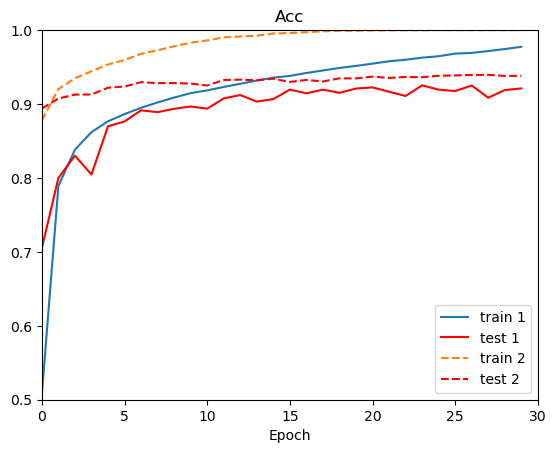

In [28]:
plot_two_runs(nepochs, acc_hist, acc_hist_test, acc_hist_do, acc_hist_test_do, "Acc", 0.5, 1.0)